In [15]:
import torch
import numpy as np
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

In [16]:
PROC_DIR = "."
test_df = pd.read_csv("../Datasets/test.csv")

# Ensure test_df label strings are mapped to integers using the classes mapped in labels.json
import json
from sklearn.preprocessing import LabelEncoder
with open("../api/labels.json", "r", encoding="utf-8") as f:
    labels_dict = json.load(f)
classes = [labels_dict[str(i)]["id"] for i in range(len(labels_dict))]
le = LabelEncoder()
le.fit(classes)
test_df['label'] = le.transform(test_df['label'])

In [17]:
class SignDataset(Dataset):
    def __init__(self, df):
        self.df = df

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        x = np.load(f"{PROC_DIR}/{row.file}").astype(np.float32)
        y = int(row.label)
        return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.df)

In [18]:
test_loader = DataLoader(SignDataset(test_df), batch_size=32)

In [19]:
# Load model
input_dim = (54+21+21+33)*3
num_classes = test_df.label.nunique()

class TransformerSignModel(torch.nn.Module):
    def __init__(self, input_dim=387, num_classes=401, d_model=256, nhead=8, num_layers=3, dropout=0.3):
        super().__init__()
        self.input_projection = torch.nn.Sequential(
            torch.nn.Linear(input_dim, d_model),
            torch.nn.LayerNorm(d_model),
            torch.nn.ReLU()
        )
        self.pos_encoder = torch.nn.Parameter(torch.randn(1, 60, d_model))
        encoder_layer = torch.nn.TransformerEncoderLayer(
            d_model=d_model, 
            nhead=nhead, 
            dim_feedforward=d_model * 4, 
            dropout=dropout,
            batch_first=True
        )
        self.transformer_encoder = torch.nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc = torch.nn.Linear(d_model, num_classes)

    def forward(self, x):
        B, T, F = x.shape
        x = self.input_projection(x)
        x = x + self.pos_encoder[:, :T, :]
        x = self.transformer_encoder(x)
        x = torch.mean(x, dim=1)
        return self.fc(x)

model = TransformerSignModel(input_dim, num_classes)
model.load_state_dict(torch.load("../Models/transformer_frontveiw.pth", map_location="cpu"))
model.eval()

TransformerSignModel(
  (input_projection): Sequential(
    (0): Linear(in_features=387, out_features=256, bias=True)
    (1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    (2): ReLU()
  )
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-2): 3 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
        )
        (linear1): Linear(in_features=256, out_features=1024, bias=True)
        (dropout): Dropout(p=0.3, inplace=False)
        (linear2): Linear(in_features=1024, out_features=256, bias=True)
        (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.3, inplace=False)
        (dropout2): Dropout(p=0.3, inplace=False)
      )
    )
  )
  (fc): Linear(in_features=256, out_features=401, bias=True)
)

In [20]:
# Predict
all_preds, all_labels = [], []

with torch.no_grad():
    for X, y in test_loader:
        preds = model(X)
        all_preds.extend(preds.argmax(1).numpy())
        all_labels.extend(y.numpy())

print(classification_report(all_labels, all_preds))

# Calculate Word Error Rate (WER)
# In word-level Sign Language Recognition (SLR), each sample is a single-word gesture.
# Therefore, incorrect predictions represent word substitutions, and WER matches (1.0 - Accuracy).
ref_words = le.inverse_transform(all_labels)
pred_words = le.inverse_transform(all_preds)

incorrect = sum(1 for r, p in zip(ref_words, pred_words) if r != p)
wer = incorrect / len(ref_words)
accuracy = 1.0 - wer

print(f"\n{'='*40}\n   WORD-LEVEL EVALUATION METRICS\n{'='*40}")
print(f"Total Test Samples: {len(ref_words)}")
print(f"Correct Words: {len(ref_words) - incorrect}")
print(f"Incorrect Words (Substitutions): {incorrect}")
print(f"Accuracy: {accuracy:.4f} ({accuracy * 100:.2f}%)")
print(f"Word Error Rate (WER): {wer:.4f} ({wer * 100:.2f}%)")

              precision    recall  f1-score   support

           0       0.73      1.00      0.84        19
           1       0.94      0.89      0.92        19
           2       0.86      0.95      0.90        20
           3       0.81      0.85      0.83        20
           4       0.94      0.89      0.92        19
           5       0.83      0.95      0.88        20
           6       0.86      0.90      0.88        20
           7       0.95      0.90      0.92        20
           8       0.89      0.85      0.87        20
           9       0.90      0.95      0.92        19
          10       0.61      0.58      0.59        19
          11       0.94      0.79      0.86        19
          12       0.75      0.83      0.79        18
          13       0.95      1.00      0.98        20
          14       1.00      1.00      1.00        19
          15       0.74      0.94      0.83        18
          16       0.95      1.00      0.98        20
          17       0.95    

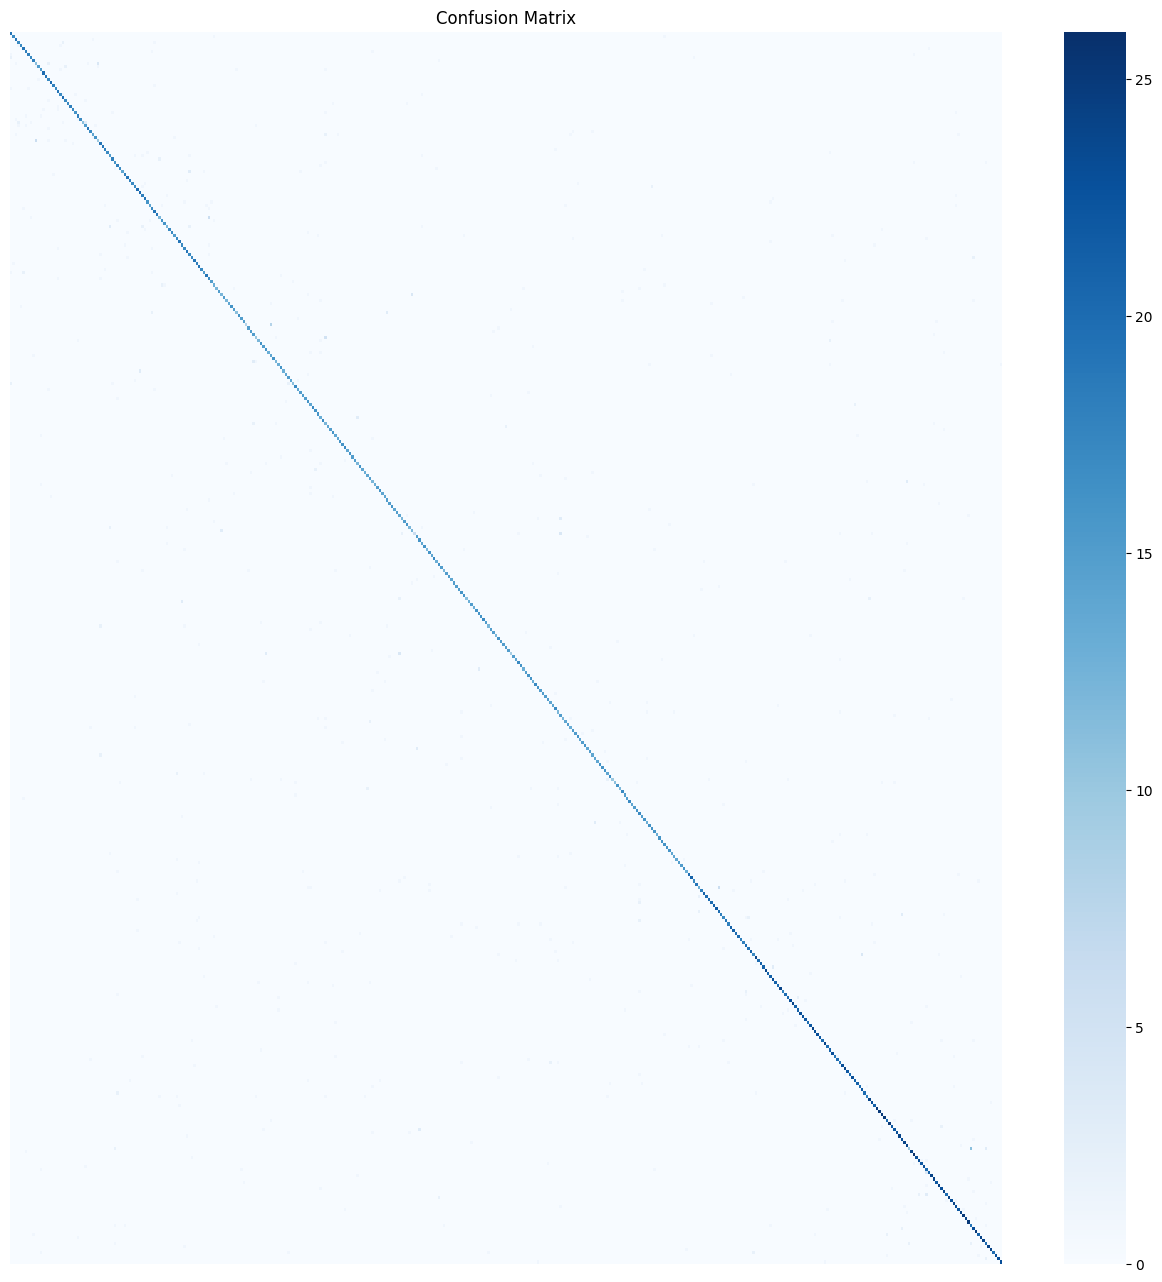

In [21]:
# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(16,16))
sns.heatmap(cm, cmap="Blues", xticklabels=False, yticklabels=False)
plt.title("Confusion Matrix")
plt.show()
